# 07 · Trees and Ensembles

[← Course home](../README.md)

**What you will learn**

- How a decision tree chooses a split: impurity measures (Gini, entropy, MSE) and the impurity decrease
- A from-scratch best-split search, verified against scikit-learn's first split
- Why trees give axis-aligned, piecewise-constant decision boundaries
- How depth controls overfitting, and how cost-complexity pruning (`ccp_alpha`) trims a tree
- Why single trees are unstable, and how **bagging** and **random forests** fix it (bootstrap, feature subsampling, OOB score)
- **Boosting**: AdaBoost in a nutshell, and gradient boosting for regression **from scratch**
- `HistGradientBoosting*`, the learning-rate / number-of-trees trade-off, and early stopping
- A cross-validated comparison of tree, random forest, gradient boosting and histogram GB on real data

In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.colors import ListedColormap
from sklearn.datasets import load_breast_cancer, load_diabetes, make_classification, make_moons
from sklearn.ensemble import (AdaBoostClassifier, BaggingClassifier, GradientBoostingClassifier,
                              GradientBoostingRegressor, HistGradientBoostingClassifier,
                              HistGradientBoostingRegressor, RandomForestClassifier,
                              RandomForestRegressor)
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold, StratifiedKFold, cross_validate, train_test_split
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_text, plot_tree

from mlaz import PALETTE, load_penguins, savefig, set_style

set_style()
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)
pd.set_option("display.precision", 4)

## 1 · Impurity: how "mixed" is a node?

A decision tree recursively splits the data into boxes. At every node it asks: *which single question
"is $x_j \le t$?" makes the two children as **pure** as possible?* Purity is measured by an **impurity**
function of the class proportions $p_k$ in the node:

$$\text{Gini}(p) = \sum_k p_k(1-p_k) = 1 - \sum_k p_k^2 \qquad\qquad
  \text{Entropy}(p) = -\sum_k p_k \log_2 p_k$$

For regression the impurity is simply the variance (mean squared error around the node mean):

$$\text{MSE}(\text{node}) = \frac{1}{n}\sum_{i \in \text{node}} (y_i - \bar y)^2 .$$

All are zero for a pure node and maximal for a 50/50 node. Let's plot them for two classes.

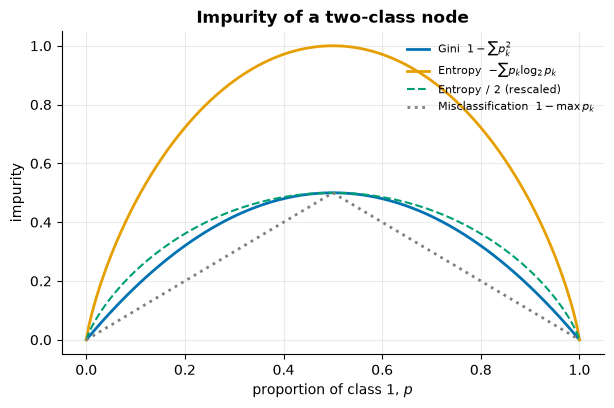

In [2]:
def gini(p):
    """Gini impurity for a vector of class proportions (last axis)."""
    p = np.asarray(p, dtype=float)
    return 1.0 - np.sum(p**2, axis=-1)


def entropy(p):
    """Shannon entropy in bits; 0*log(0) is taken to be 0."""
    p = np.asarray(p, dtype=float)
    with np.errstate(divide="ignore", invalid="ignore"):
        terms = np.where(p > 0, -p * np.log2(p), 0.0)
    return terms.sum(axis=-1)


p = np.linspace(0, 1, 201)
P = np.column_stack([p, 1 - p])
misclass = 1 - np.max(P, axis=1)

fig, ax = plt.subplots()
ax.plot(p, gini(P), label="Gini  $1-\\sum p_k^2$", lw=2)
ax.plot(p, entropy(P), label="Entropy  $-\\sum p_k\\log_2 p_k$", lw=2)
ax.plot(p, entropy(P) / 2, "--", label="Entropy / 2 (rescaled)", lw=1.5)
ax.plot(p, misclass, ":", label="Misclassification  $1-\\max p_k$", lw=2, color="gray")
ax.set(title="Impurity of a two-class node", xlabel="proportion of class 1, $p$",
       ylabel="impurity")
ax.legend(loc="upper right", fontsize=8)
savefig("impurity_curves")
plt.show()

Gini and (rescaled) entropy are almost identical in shape — in practice they pick the same split most of the
time. Both are **strictly concave**, unlike misclassification error, which is why they reward splits that make
a node *purer* even when the majority class does not change.

## 2 · Finding the best split from scratch

For a candidate split of a parent node $P$ into $L$ and $R$, the tree maximises the **weighted impurity decrease**

$$\Delta I = I(P) - \frac{n_L}{n_P} I(L) - \frac{n_R}{n_P} I(R).$$

For a single numeric feature we sort the values and try every midpoint between consecutive distinct values.
Using cumulative class counts this is $O(n)$ after sorting. We do this for every feature of the breast-cancer
data and keep the winner.

In [3]:
cancer = load_breast_cancer(as_frame=True)
Xc, yc = cancer.data, cancer.target  # target: 1 = benign, 0 = malignant
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(Xc, yc, test_size=0.25, stratify=yc,
                                              random_state=RANDOM_STATE)
print(Xc_tr.shape, "class balance (benign share):", yc_tr.mean().round(3))

(426, 30) class balance (benign share): 0.627


In [4]:
def best_split_one_feature(x, y, impurity=gini):
    """Exhaustive best threshold for ONE numeric feature.

    Returns (best_threshold, best_decrease, thresholds, decreases).
    """
    order = np.argsort(x, kind="stable")
    xs, ys = x[order], y[order]
    classes = np.unique(y)
    onehot = (ys[:, None] == classes[None, :]).astype(float)   # n x K
    left_counts = np.cumsum(onehot, axis=0)[:-1]              # counts in L if we split after row i
    total = onehot.sum(axis=0)
    right_counts = total - left_counts
    n = len(y)
    n_left = np.arange(1, n)
    n_right = n - n_left
    valid = xs[1:] > xs[:-1]                                    # only split between distinct values
    imp_parent = impurity(total / n)
    imp_left = impurity(left_counts / n_left[:, None])
    imp_right = impurity(right_counts / n_right[:, None])
    decrease = imp_parent - (n_left / n) * imp_left - (n_right / n) * imp_right
    thresholds = (xs[1:] + xs[:-1]) / 2                         # midpoints, like sklearn
    thresholds, decrease = thresholds[valid], decrease[valid]
    i = np.argmax(decrease)
    return thresholds[i], decrease[i], thresholds, decrease


def best_split(X, y, impurity=gini):
    """Loop over features and keep the best (feature, threshold)."""
    rows = []
    for j, name in enumerate(X.columns):
        t, d, _, _ = best_split_one_feature(X.iloc[:, j].to_numpy(), y.to_numpy(), impurity)
        rows.append((name, t, d))
    table = pd.DataFrame(rows, columns=["feature", "threshold", "gini_decrease"])
    return table.sort_values("gini_decrease", ascending=False).reset_index(drop=True)


split_table = best_split(Xc_tr, yc_tr)
split_table.head(5)

,feature,threshold,gini_decrease
0,worst perimeter,112.8000,0.3254
1,worst radius,16.7950,0.3254
2,worst area,884.7500,0.3222
3,worst concave points,0.1455,0.3218
4,mean concave points,0.0514,0.3190


Now the same with scikit-learn: a depth-1 tree (a **decision stump**) stores its split in `tree_.feature[0]`
and `tree_.threshold[0]`.

In [5]:
stump = DecisionTreeClassifier(max_depth=1, random_state=RANDOM_STATE).fit(Xc_tr, yc_tr)
sk_feature = Xc.columns[stump.tree_.feature[0]]
sk_threshold = stump.tree_.threshold[0]
imp = stump.tree_.impurity
n_node = stump.tree_.weighted_n_node_samples
sk_decrease = imp[0] - (n_node[1] * imp[1] + n_node[2] * imp[2]) / n_node[0]

print(f"scikit-learn : {sk_feature:<22s} <= {sk_threshold:.4f}  ΔGini = {sk_decrease:.5f}")
ties = split_table[np.isclose(split_table.gini_decrease, split_table.gini_decrease.max())]
print(f"\nfrom scratch, all splits tied for the best ΔGini = {ties.gini_decrease.iloc[0]:.5f}:")
print(ties.to_string(index=False))
print("\nsklearn's split is one of our tied optima:",
      any((ties.feature == sk_feature) & np.isclose(ties.threshold, sk_threshold)))

scikit-learn : worst radius           <= 16.7950  ΔGini = 0.32538

from scratch, all splits tied for the best ΔGini = 0.32538:
        feature  threshold  gini_decrease
worst perimeter    112.800         0.3254
   worst radius     16.795         0.3254

sklearn's split is one of our tied optima: True


Interesting! Two features — `worst perimeter` and `worst radius` — produce **exactly the same partition** of the
training set (perimeter ≈ 2π·radius, so they sort the tumours identically), hence the same impurity decrease.
scikit-learn visits features in a random order (controlled by `random_state`) and keeps the first best one it
finds, so which of the tied features "wins" is arbitrary. To compare like with like, let's check the
**single-feature** search: for each feature, a stump fitted on that column alone must pick our threshold.

In [6]:
rows = []
for f in Xc.columns[:8]:
    t_ours, d_ours, _, _ = best_split_one_feature(Xc_tr[f].to_numpy(), yc_tr.to_numpy())
    s1 = DecisionTreeClassifier(max_depth=1).fit(Xc_tr[[f]], yc_tr)
    rows.append((f, t_ours, s1.tree_.threshold[0], np.isclose(t_ours, s1.tree_.threshold[0])))
pd.DataFrame(rows, columns=["feature", "scratch threshold", "sklearn threshold", "match"])

,feature,scratch threshold,sklearn threshold,match
0,mean radius,15.0450,15.0450,True
1,mean texture,18.6350,18.6350,True
2,mean perimeter,98.8250,98.8250,True
3,mean area,696.2500,696.2500,True
4,mean smoothness,0.0896,0.0896,True
5,mean compactness,0.1022,0.1022,True
6,mean concavity,0.0933,0.0933,True
7,mean concave points,0.0514,0.0514,True


Every single-feature threshold matches. Let's look at the decrease as a function of the threshold
for the winning feature — the tree picks the peak.

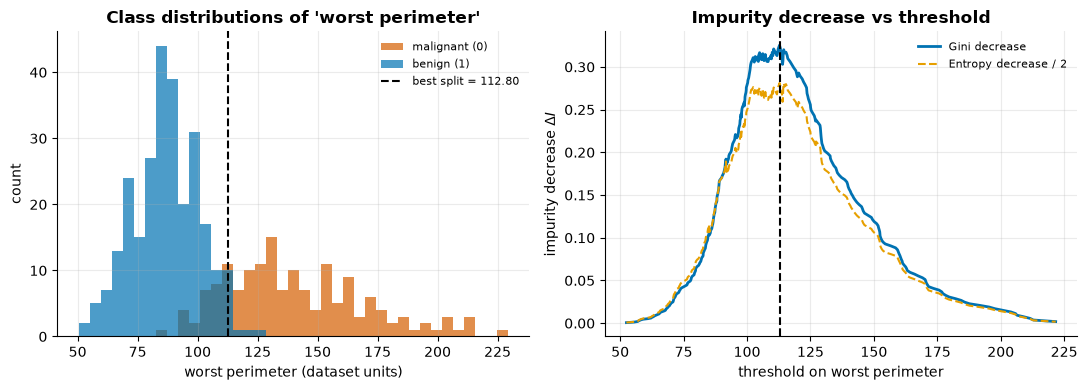

In [7]:
feat = split_table.feature[0]
t_best, d_best, ts, ds = best_split_one_feature(Xc_tr[feat].to_numpy(), yc_tr.to_numpy())
_, _, ts_e, ds_e = best_split_one_feature(Xc_tr[feat].to_numpy(), yc_tr.to_numpy(), entropy)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
ax = axes[0]
bins = np.linspace(Xc_tr[feat].min(), Xc_tr[feat].max(), 40)
ax.hist(Xc_tr.loc[yc_tr == 0, feat], bins=bins, alpha=0.7, label="malignant (0)", color=PALETTE[3])
ax.hist(Xc_tr.loc[yc_tr == 1, feat], bins=bins, alpha=0.7, label="benign (1)", color=PALETTE[0])
ax.axvline(t_best, color="k", ls="--", label=f"best split = {t_best:.2f}")
ax.set(title=f"Class distributions of '{feat}'", xlabel=f"{feat} (dataset units)", ylabel="count")
ax.legend(fontsize=8)
ax = axes[1]
ax.plot(ts, ds, label="Gini decrease", lw=2)
ax.plot(ts_e, ds_e / 2, label="Entropy decrease / 2", lw=1.5, ls="--")
ax.axvline(t_best, color="k", ls="--")
ax.set(title="Impurity decrease vs threshold", xlabel=f"threshold on {feat}",
       ylabel="impurity decrease $\\Delta I$")
ax.legend(fontsize=8)
fig.tight_layout()
savefig("split_search")
plt.show()

## 3 · Reading a tree: `plot_tree`

Trees are famously easy to read. We use the Palmer penguins with two numeric features so we can also draw the
decision regions afterwards.

In [8]:
peng = load_penguins().dropna(subset=["bill_length_mm", "flipper_length_mm"])
feat2 = ["bill_length_mm", "flipper_length_mm"]
Xp = peng[feat2].to_numpy()
species = peng["species"].astype("category")
yp = species.cat.codes.to_numpy()
class_names = list(species.cat.categories)
Xp_tr, Xp_te, yp_tr, yp_te = train_test_split(Xp, yp, test_size=0.3, stratify=yp,
                                              random_state=RANDOM_STATE)

tree3 = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE).fit(Xp_tr, yp_tr)
print(f"depth-3 tree: train acc = {tree3.score(Xp_tr, yp_tr):.3f}, test acc = {tree3.score(Xp_te, yp_te):.3f}")
print(export_text(tree3, feature_names=feat2, decimals=1))

depth-3 tree: train acc = 0.941, test acc = 0.971
|--- flipper_length_mm <= 206.5
|   |--- bill_length_mm <= 43.4
|   |   |--- bill_length_mm <= 42.3
|   |   |   |--- class: 0
|   |   |--- bill_length_mm >  42.3
|   |   |   |--- class: 0
|   |--- bill_length_mm >  43.4
|   |   |--- bill_length_mm <= 46.2
|   |   |   |--- class: 1
|   |   |--- bill_length_mm >  46.2
|   |   |   |--- class: 1
|--- flipper_length_mm >  206.5
|   |--- bill_length_mm <= 41.2
|   |   |--- class: 0
|   |--- bill_length_mm >  41.2
|   |   |--- flipper_length_mm <= 212.5
|   |   |   |--- class: 2
|   |   |--- flipper_length_mm >  212.5
|   |   |   |--- class: 2



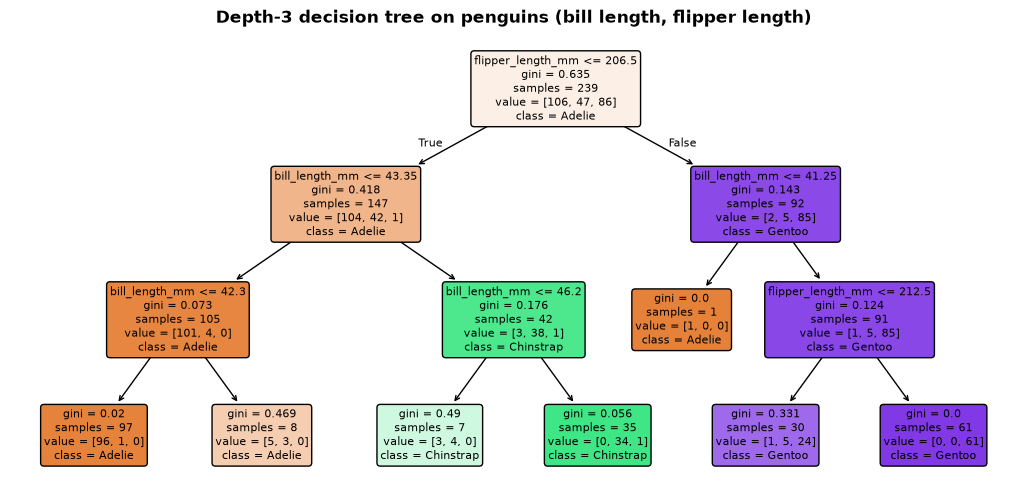

In [9]:
fig, ax = plt.subplots(figsize=(13, 6))
plot_tree(tree3, feature_names=feat2, class_names=class_names, filled=True, rounded=True,
          impurity=True, fontsize=8, ax=ax)
ax.set_title("Depth-3 decision tree on penguins (bill length, flipper length)")
savefig("tree_plot")
plt.show()

Each box shows the question, the node's Gini impurity, its sample count, the class counts (`value`) and the
majority class. A prediction is just a walk from the root to a leaf.

Notice that some sibling leaves predict the **same** class (e.g. both children of `bill_length_mm <= 42.3`
say *Adelie*). The split was still worth making for the tree: it lowers Gini impurity (one leaf becomes almost
pure) even though it does not change any prediction — exactly the concavity argument from section 1.

## 4 · Axis-aligned decision boundaries and depth

Every split is a threshold on **one** feature, so decision regions are unions of axis-aligned rectangles.
A diagonal boundary has to be approximated by a staircase. Let's compare depths 1, 3 and unlimited on the
penguins and on the (noisy) two-moons toy data.

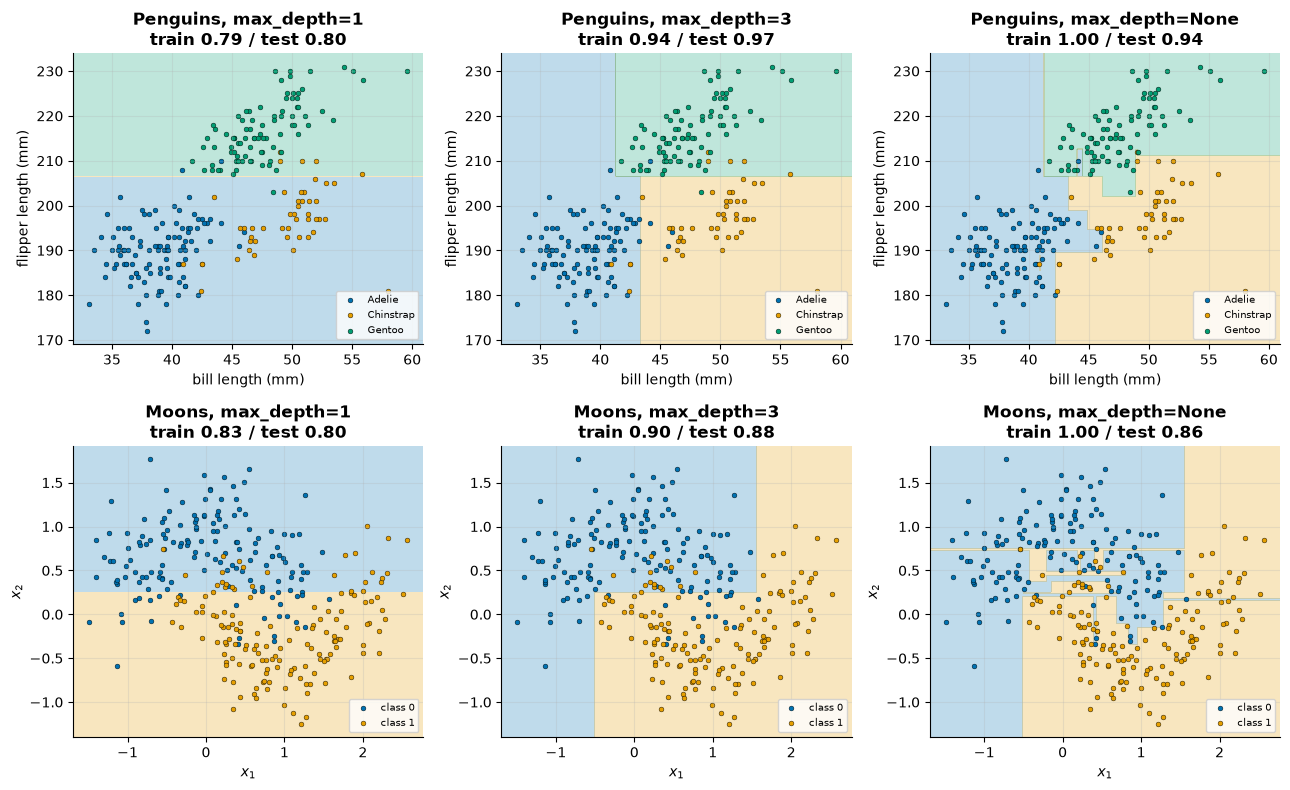

In [10]:
def plot_regions(model, X, y, ax, title, xlabel="$x_1$", ylabel="$x_2$", n_classes=None, h=300, labels=None):
    n_classes = n_classes or len(np.unique(y))
    cmap = ListedColormap(PALETTE[:n_classes])
    x0, x1 = X[:, 0].min() - 0.05 * np.ptp(X[:, 0]), X[:, 0].max() + 0.05 * np.ptp(X[:, 0])
    y0, y1 = X[:, 1].min() - 0.05 * np.ptp(X[:, 1]), X[:, 1].max() + 0.05 * np.ptp(X[:, 1])
    xx, yy = np.meshgrid(np.linspace(x0, x1, h), np.linspace(y0, y1, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap=cmap, levels=np.arange(n_classes + 1) - 0.5)
    labels = labels or [f"class {k}" for k in range(n_classes)]
    for k in range(n_classes):
        ax.scatter(X[y == k, 0], X[y == k, 1], color=PALETTE[k], s=12, edgecolor="k", linewidth=0.3,
                   label=labels[k])
    ax.set(title=title, xlabel=xlabel, ylabel=ylabel)
    ax.legend(fontsize=7, loc="lower right", framealpha=0.8, frameon=True)


Xm, ym = make_moons(n_samples=500, noise=0.3, random_state=RANDOM_STATE)
Xm_tr, Xm_te, ym_tr, ym_te = train_test_split(Xm, ym, test_size=0.4, random_state=RANDOM_STATE)

fig, axes = plt.subplots(2, 3, figsize=(13, 8))
for col, depth in enumerate([1, 3, None]):
    t = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE).fit(Xp_tr, yp_tr)
    plot_regions(t, Xp_tr, yp_tr, axes[0, col],
                 f"Penguins, max_depth={depth}\ntrain {t.score(Xp_tr, yp_tr):.2f} / test {t.score(Xp_te, yp_te):.2f}",
                 xlabel="bill length (mm)", ylabel="flipper length (mm)", labels=class_names)
    t = DecisionTreeClassifier(max_depth=depth, random_state=RANDOM_STATE).fit(Xm_tr, ym_tr)
    plot_regions(t, Xm_tr, ym_tr, axes[1, col],
                 f"Moons, max_depth={depth}\ntrain {t.score(Xm_tr, ym_tr):.2f} / test {t.score(Xm_te, ym_te):.2f}")
fig.tight_layout()
savefig("decision_boundaries_depth")
plt.show()

With unlimited depth the tree keeps splitting until every leaf is pure: 100 % training accuracy, tiny
islands around individual noisy points — classic **overfitting**. Let's sweep `max_depth` systematically
with 5-fold cross-validation on the moons training set.

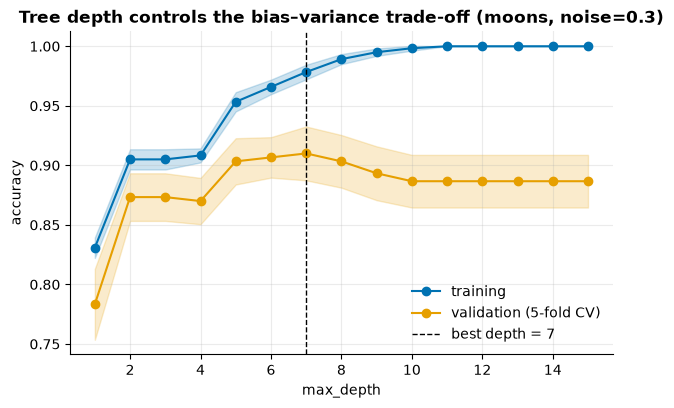

best max_depth = 7, CV accuracy = 0.910; depth 15 CV accuracy = 0.887


In [11]:
depths = np.arange(1, 16)
train_scores, val_scores = [], []
for d in depths:
    cv = cross_validate(DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE), Xm_tr, ym_tr,
                        cv=5, return_train_score=True)
    train_scores.append(cv["train_score"])
    val_scores.append(cv["test_score"])
train_scores, val_scores = np.array(train_scores), np.array(val_scores)
best_depth = depths[val_scores.mean(1).argmax()]

fig, ax = plt.subplots()
for s, lab, c in [(train_scores, "training", PALETTE[0]), (val_scores, "validation (5-fold CV)", PALETTE[1])]:
    ax.plot(depths, s.mean(1), "o-", label=lab, color=c)
    ax.fill_between(depths, s.mean(1) - s.std(1), s.mean(1) + s.std(1), alpha=0.2, color=c)
ax.axvline(best_depth, color="k", ls="--", lw=1, label=f"best depth = {best_depth}")
ax.set(title="Tree depth controls the bias–variance trade-off (moons, noise=0.3)",
       xlabel="max_depth", ylabel="accuracy")
ax.legend()
savefig("depth_overfitting")
plt.show()
print(f"best max_depth = {best_depth}, CV accuracy = {val_scores.mean(1).max():.3f}; "
      f"depth 15 CV accuracy = {val_scores[-1].mean():.3f}")

## 5 · Cost-complexity pruning

Instead of stopping early (`max_depth`, `min_samples_leaf`, …) we can grow a full tree and then **prune** it.
CART's minimal cost-complexity pruning minimises

$$R_\alpha(T) = R(T) + \alpha\,|T|,$$

where $R(T)$ is the total (sample-weighted) leaf impurity and $|T|$ the number of leaves. Increasing $\alpha$
removes the "weakest link" subtrees one by one. `cost_complexity_pruning_path` returns the sequence of
effective alphas; we pick one by cross-validation.

In [12]:
path = DecisionTreeClassifier(random_state=RANDOM_STATE).cost_complexity_pruning_path(Xc_tr, yc_tr)
alphas, impurities = path.ccp_alphas[:-1], path.impurities[:-1]   # last alpha prunes to the root
rows = []
for a in alphas:
    t = DecisionTreeClassifier(ccp_alpha=a, random_state=RANDOM_STATE)
    cv = cross_validate(t, Xc_tr, yc_tr, cv=StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
                        return_train_score=True)
    t.fit(Xc_tr, yc_tr)
    rows.append(dict(alpha=a, leaves=t.get_n_leaves(), depth=t.get_depth(),
                     train=cv["train_score"].mean(), cv=cv["test_score"].mean(),
                     test=t.score(Xc_te, yc_te)))
prune = pd.DataFrame(rows)
best = prune.loc[prune.cv.idxmax()]
print(f"{len(alphas)} candidate alphas. Best ccp_alpha = {best.alpha:.4f} -> "
      f"{int(best.leaves)} leaves, CV acc = {best.cv:.3f}, test acc = {best.test:.3f}")
print(f"Unpruned tree: {int(prune.leaves[0])} leaves, CV acc = {prune.cv[0]:.3f}, test acc = {prune.test[0]:.3f}")

12 candidate alphas. Best ccp_alpha = 0.0149 -> 4 leaves, CV acc = 0.937, test acc = 0.909
Unpruned tree: 18 leaves, CV acc = 0.925, test acc = 0.923


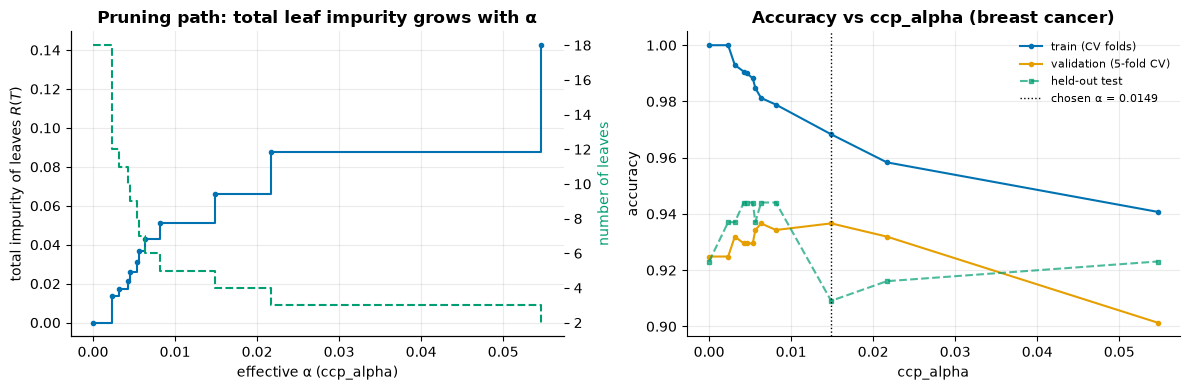

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].step(alphas, impurities, where="post", marker="o", ms=3)
axes[0].set(title="Pruning path: total leaf impurity grows with α", xlabel="effective α (ccp_alpha)",
            ylabel="total impurity of leaves $R(T)$")
ax2 = axes[0].twinx()
ax2.step(alphas, prune.leaves, where="post", color=PALETTE[2], ls="--")
ax2.set_ylabel("number of leaves", color=PALETTE[2])
ax2.grid(False)
axes[1].plot(prune.alpha, prune.train, "o-", ms=3, label="train (CV folds)")
axes[1].plot(prune.alpha, prune.cv, "o-", ms=3, label="validation (5-fold CV)")
axes[1].plot(prune.alpha, prune.test, "s--", ms=3, label="held-out test", alpha=0.7)
axes[1].axvline(best.alpha, color="k", ls=":", lw=1, label=f"chosen α = {best.alpha:.4f}")
axes[1].set(title="Accuracy vs ccp_alpha (breast cancer)", xlabel="ccp_alpha", ylabel="accuracy")
axes[1].legend(fontsize=8)
fig.tight_layout()
savefig("ccp_pruning")
plt.show()

Pruning removes 14 of the 18 leaves while *improving* the cross-validated accuracy. The held-out test accuracy
moves the other way here (0.923 → 0.909) — that is a difference of just **two** of the 143 test tumours and a
good reminder that a single small test set is a noisy yardstick; the 5-fold CV curve averages over more data.
Choose hyperparameters with CV, and treat the test score as a final sanity check, not a tuning signal.

## 6 · Trees are unstable

Trees have **low bias but high variance**: a small change in the data can change the root split and hence the
whole tree. Below, four fully grown trees trained on four bootstrap samples (draw $n$ rows *with replacement*)
of the same moons training set.

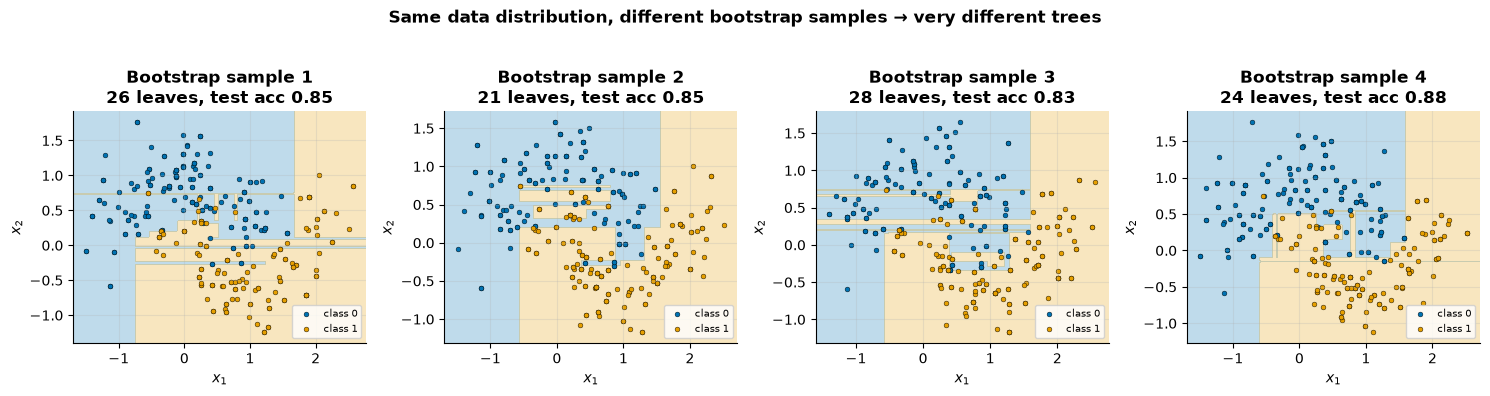

,root feature,root threshold,n_leaves
0,x2,0.118,26
1,x2,0.206,21
2,x2,0.158,28
3,x2,-0.093,24


In [14]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.8))
root_splits = []
for b, ax in enumerate(axes):
    idx = rng.integers(0, len(Xm_tr), len(Xm_tr))
    t = DecisionTreeClassifier(random_state=RANDOM_STATE).fit(Xm_tr[idx], ym_tr[idx])
    root_splits.append((f"x{t.tree_.feature[0] + 1}", round(t.tree_.threshold[0], 3), t.get_n_leaves()))
    plot_regions(t, Xm_tr[idx], ym_tr[idx], ax,
                 f"Bootstrap sample {b + 1}\n{t.get_n_leaves()} leaves, test acc {t.score(Xm_te, ym_te):.2f}")
fig.suptitle("Same data distribution, different bootstrap samples → very different trees", y=1.03,
             fontweight="bold")
fig.tight_layout()
savefig("tree_instability")
plt.show()
pd.DataFrame(root_splits, columns=["root feature", "root threshold", "n_leaves"])

## 7 · Bagging and random forests

**Bagging** (bootstrap aggregating, Breiman 1996) exploits this variance: train $B$ trees on $B$ bootstrap
samples and average their predictions (majority vote / mean of probabilities). If each tree has variance
$\sigma^2$ and pairwise correlation $\rho$, the average has variance

$$\operatorname{Var}\Big(\frac1B\sum_{b=1}^B T_b(x)\Big) = \rho\,\sigma^2 + \frac{1-\rho}{B}\,\sigma^2 .$$

More trees kill the second term, but the first term $\rho\sigma^2$ stays. **Random forests** (Breiman 2001)
reduce $\rho$ by also drawing a random subset of `max_features` candidate features **at every split**
(default $\sqrt{p}$ for classification), so the trees disagree more and the average improves.

Each bootstrap sample leaves out about $(1-1/n)^n \approx e^{-1} \approx 36.8\%$ of the rows. Predicting each
row using only the trees that did *not* see it gives the **out-of-bag (OOB) score** — a free validation
estimate.

In [15]:
n = len(Xc_tr)
print(f"P(row not in a bootstrap sample) = (1 - 1/n)^n = {(1 - 1 / n) ** n:.4f}  (e^-1 = {np.exp(-1):.4f})")
idx = rng.integers(0, n, n)
print(f"empirical OOB fraction in one sample: {1 - len(np.unique(idx)) / n:.4f}")

P(row not in a bootstrap sample) = (1 - 1/n)^n = 0.3674  (e^-1 = 0.3679)
empirical OOB fraction in one sample: 0.3967


A quick simulation of the variance formula: average $B$ correlated noisy "trees" and measure the variance.

In [16]:
sigma2, B_values = 1.0, [1, 5, 25, 100]
sim = []
for rho in [0.0, 0.3, 0.7]:
    cov = sigma2 * (rho * np.ones((100, 100)) + (1 - rho) * np.eye(100))
    draws = rng.multivariate_normal(np.zeros(100), cov, size=20000)
    for B in B_values:
        sim.append(dict(rho=rho, B=B, simulated=draws[:, :B].mean(1).var(),
                        formula=rho * sigma2 + (1 - rho) * sigma2 / B))
pd.DataFrame(sim).pivot(index="B", columns="rho", values=["simulated", "formula"]).round(3)

simulated               formula              
rho       0.0    0.3    0.7     0.0    0.3    0.7
B                                                
1       0.990  0.994  0.994    1.00  1.000  1.000
5       0.199  0.430  0.754    0.20  0.440  0.760
25      0.039  0.322  0.710    0.04  0.328  0.712
100     0.010  0.302  0.701    0.01  0.307  0.703

Now the real thing. Breast cancer is almost too easy (a few errors out of 426 rows), so for the OOB curves we use a
harder synthetic problem: 1 000 samples, 25 features of which only 6 are informative and 6 are redundant
linear combinations. We compare plain bagging (`max_features=1.0`: all 25 features are candidates at every
split), a random forest with the default `max_features="sqrt"` (5 of 25), and an extreme forest with
`max_features=1` (a random feature per split). `warm_start=True` adds trees incrementally.

Bagging (max_features=1.0)             500 trees: OOB error = 0.120, test error = 0.147


Random forest (max_features='sqrt')    500 trees: OOB error = 0.106, test error = 0.143


Random forest (max_features=1)         500 trees: OOB error = 0.124, test error = 0.150


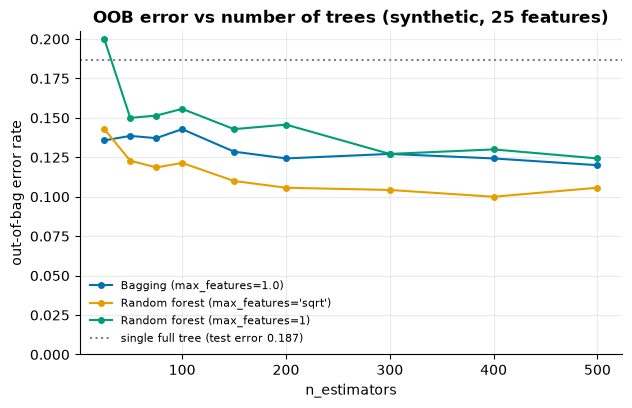

,25,50,75,100,150,200,300,400,500
Bagging (max_features=1.0),0.1357,0.1386,0.1371,0.1429,0.1286,0.1243,0.1271,0.1243,0.1200
Random forest (max_features='sqrt'),0.1429,0.1229,0.1186,0.1214,0.1100,0.1057,0.1043,0.1000,0.1057
Random forest (max_features=1),0.2000,0.1500,0.1514,0.1557,0.1429,0.1457,0.1271,0.1300,0.1243


In [17]:
Xs, ys = make_classification(n_samples=1000, n_features=25, n_informative=6, n_redundant=6, flip_y=0.03,
                             random_state=RANDOM_STATE)
Xs_tr, Xs_te, ys_tr, ys_te = train_test_split(Xs, ys, test_size=0.3, random_state=RANDOM_STATE)
n_trees = [25, 50, 75, 100, 150, 200, 300, 400, 500]
settings = {"Bagging (max_features=1.0)": 1.0, "Random forest (max_features='sqrt')": "sqrt",
            "Random forest (max_features=1)": 1}
oob = {name: [] for name in settings}
for name, mf in settings.items():
    rf = RandomForestClassifier(max_features=mf, oob_score=True, warm_start=True,
                                random_state=RANDOM_STATE, n_jobs=-1)
    for nt in n_trees:
        rf.set_params(n_estimators=nt).fit(Xs_tr, ys_tr)
        oob[name].append(1 - rf.oob_score_)
    print(f"{name:<38s} 500 trees: OOB error = {oob[name][-1]:.3f}, test error = {1 - rf.score(Xs_te, ys_te):.3f}")

single_tree_err = 1 - DecisionTreeClassifier(random_state=RANDOM_STATE).fit(Xs_tr, ys_tr).score(Xs_te, ys_te)
fig, ax = plt.subplots()
for name, errs in oob.items():
    ax.plot(n_trees, errs, "o-", ms=4, label=name)
ax.axhline(single_tree_err, color="gray", ls=":", label=f"single full tree (test error {single_tree_err:.3f})")
ax.set(title="OOB error vs number of trees (synthetic, 25 features)", xlabel="n_estimators",
       ylabel="out-of-bag error rate", ylim=(0, None))
ax.legend(fontsize=8)
savefig("rf_oob_error")
plt.show()
pd.DataFrame(oob, index=n_trees).T.round(4)

In [18]:
rf = RandomForestClassifier(n_estimators=300, oob_score=True, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(Xc_tr, yc_tr)
print(f"Random forest (300 trees): OOB accuracy = {rf.oob_score_:.3f}, test accuracy = {rf.score(Xc_te, yc_te):.3f}")
bag = BaggingClassifier(DecisionTreeClassifier(), n_estimators=300, oob_score=True,
                        random_state=RANDOM_STATE, n_jobs=-1).fit(Xc_tr, yc_tr)
print(f"BaggingClassifier(tree) : OOB accuracy = {bag.oob_score_:.3f}, test accuracy = {bag.score(Xc_te, yc_te):.3f}")

Random forest (300 trees): OOB accuracy = 0.962, test accuracy = 0.958


BaggingClassifier(tree) : OOB accuracy = 0.958, test accuracy = 0.951


Back on breast cancer, the OOB estimate lands close to the held-out test accuracy without spending any data on validation.
Adding trees never *hurts* a forest (it only reduces the variance term) — it just costs time; the curve
flattens once the $\rho\sigma^2$ floor dominates.

Impurity-based `feature_importances_` come for free (but are biased toward high-cardinality features; see
chapter 11 for permutation importance):

In [19]:
pd.Series(rf.feature_importances_, index=Xc.columns).sort_values(ascending=False).head(8).round(3)

worst perimeter         0.146
worst area              0.144
worst concave points    0.115
mean concave points     0.098
worst radius            0.072
mean radius             0.061
mean perimeter          0.056
mean concavity          0.045
dtype: float64

## 8 · Boosting

Bagging builds strong, low-bias trees **in parallel** and averages away their variance. **Boosting** builds
weak, high-bias learners (shallow trees) **sequentially**, each one focusing on what the ensemble so far gets
wrong — it mainly reduces **bias**.

### 8.1 · AdaBoost in one paragraph

AdaBoost (Freund & Schapire 1997) keeps a weight on every training sample. After fitting a weak learner
$h_m$ with weighted error $\varepsilon_m$, it gets a say $\alpha_m = \tfrac12\ln\frac{1-\varepsilon_m}{\varepsilon_m}$,
and the weights of misclassified samples are multiplied by $e^{\alpha_m}$ (then renormalised). The final
classifier is $\operatorname{sign}\big(\sum_m \alpha_m h_m(x)\big)$. It turns out to be forward stagewise
additive modelling with the **exponential loss** — which leads us to gradient boosting.

In [20]:
for n_est in [1, 10, 50, 200]:
    ada = AdaBoostClassifier(DecisionTreeClassifier(max_depth=1), n_estimators=n_est,
                             random_state=RANDOM_STATE).fit(Xc_tr, yc_tr)
    print(f"AdaBoost with {n_est:>3d} stumps: train acc = {ada.score(Xc_tr, yc_tr):.3f}, "
          f"test acc = {ada.score(Xc_te, yc_te):.3f}")

AdaBoost with   1 stumps: train acc = 0.923, test acc = 0.923
AdaBoost with  10 stumps: train acc = 0.981, test acc = 0.951


AdaBoost with  50 stumps: train acc = 1.000, test acc = 0.965


AdaBoost with 200 stumps: train acc = 1.000, test acc = 0.972


### 8.2 · Gradient boosting from scratch (regression, squared loss)

Gradient boosting (Friedman 2001) builds an additive model

$$F_M(x) = F_0 + \nu \sum_{m=1}^{M} h_m(x)$$

one tree at a time. At stage $m$ we fit tree $h_m$ to the **negative gradient** of the loss w.r.t. the current
predictions. For squared loss $L = \tfrac12 (y - F)^2$ this is just the **residual**:

$$r_{im} = -\frac{\partial L(y_i, F)}{\partial F}\Big|_{F=F_{m-1}(x_i)} = y_i - F_{m-1}(x_i).$$

So the algorithm is:

1. $F_0 = \bar y$ (the constant minimising squared loss).
2. For $m = 1..M$: compute residuals $r_i = y_i - F_{m-1}(x_i)$, fit a small regression tree $h_m$ to
   $(x_i, r_i)$, update $F_m = F_{m-1} + \nu\, h_m$.

The **learning rate** (shrinkage) $0 < \nu \le 1$ makes each step small, so more trees are needed but the fit
generalises better. Let's implement it on a 1-D toy problem.

In [21]:
x_toy = np.sort(rng.uniform(0, 10, 120))
y_toy = np.sin(x_toy) + 0.3 * x_toy + rng.normal(0, 0.35, x_toy.size)
X_toy = x_toy.reshape(-1, 1)


class ScratchGBR:
    """Gradient boosting for regression with squared loss, built from sklearn regression trees."""

    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=2, random_state=None):
        self.n_estimators, self.learning_rate = n_estimators, learning_rate
        self.max_depth, self.random_state = max_depth, random_state

    def fit(self, X, y):
        self.init_ = y.mean()                          # F_0
        F = np.full(len(y), self.init_)
        self.trees_ = []
        for _ in range(self.n_estimators):
            residuals = y - F                           # negative gradient of 1/2 (y - F)^2
            tree = DecisionTreeRegressor(max_depth=self.max_depth, criterion="squared_error",
                                         random_state=self.random_state).fit(X, residuals)
            F += self.learning_rate * tree.predict(X)
            self.trees_.append(tree)
        return self

    def staged_predict(self, X):
        F = np.full(X.shape[0], self.init_)
        for tree in self.trees_:
            F = F + self.learning_rate * tree.predict(X)
            yield F

    def predict(self, X):
        *_, last = self.staged_predict(X)
        return last


gb_scratch = ScratchGBR(n_estimators=200, learning_rate=0.1, max_depth=2, random_state=RANDOM_STATE)
gb_scratch.fit(X_toy, y_toy)
gb_sklearn = GradientBoostingRegressor(n_estimators=200, learning_rate=0.1, max_depth=2,
                                       random_state=RANDOM_STATE).fit(X_toy, y_toy)
x_grid = np.linspace(0, 10, 500).reshape(-1, 1)
p_scratch, p_sklearn = gb_scratch.predict(x_grid), gb_sklearn.predict(x_grid)
print("max |scratch - sklearn| on grid:", np.abs(p_scratch - p_sklearn).max())
print("allclose:", np.allclose(p_scratch, p_sklearn))
print(f"train MSE scratch = {mean_squared_error(y_toy, gb_scratch.predict(X_toy)):.5f}, "
      f"sklearn = {mean_squared_error(y_toy, gb_sklearn.predict(X_toy)):.5f}")

max |scratch - sklearn| on grid: 0.0
allclose: True
train MSE scratch = 0.03093, sklearn = 0.03093


Our 20-line implementation reproduces `GradientBoostingRegressor` to floating-point precision. Now watch the
stages: top row = ensemble prediction $F_m$, bottom row = residuals $y - F_{m-1}$ with the tree $h_m$ that was
fitted to them.

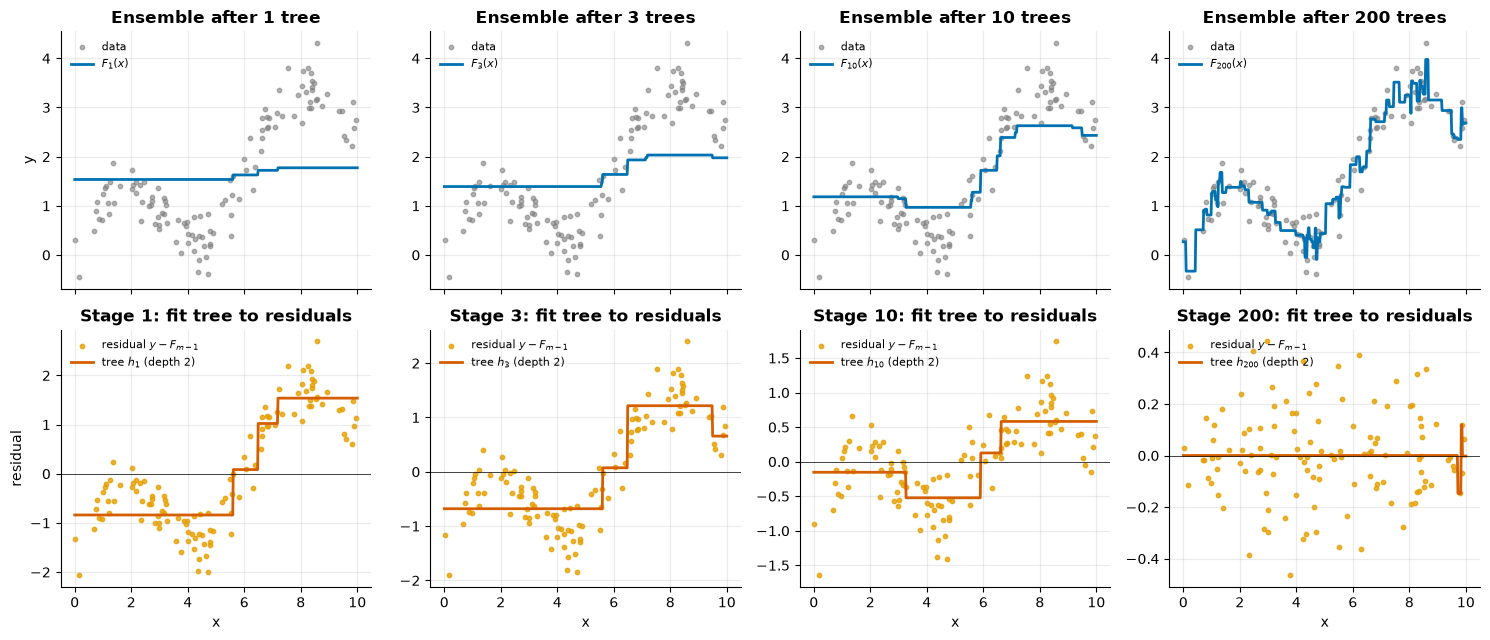

In [22]:
stages = [1, 3, 10, 200]
staged_grid = list(gb_scratch.staged_predict(x_grid))
staged_train = list(gb_scratch.staged_predict(X_toy))
fig, axes = plt.subplots(2, 4, figsize=(15, 6.5), sharex=True)
for col, m in enumerate(stages):
    ax = axes[0, col]
    ax.scatter(x_toy, y_toy, s=10, color="gray", alpha=0.6, label="data")
    ax.plot(x_grid, staged_grid[m - 1], color=PALETTE[0], lw=2, label=f"$F_{{{m}}}(x)$")
    ax.set(title=f"Ensemble after {m} tree{'s' if m > 1 else ''}", ylabel="y" if col == 0 else None)
    ax.legend(fontsize=8, loc="upper left")
    ax = axes[1, col]
    F_prev = np.full_like(y_toy, gb_scratch.init_) if m == 1 else staged_train[m - 2]
    ax.scatter(x_toy, y_toy - F_prev, s=10, color=PALETTE[1], alpha=0.8, label="residual $y - F_{m-1}$")
    ax.plot(x_grid, gb_scratch.trees_[m - 1].predict(x_grid), color=PALETTE[3], lw=2,
            label=f"tree $h_{{{m}}}$ (depth 2)")
    ax.axhline(0, color="k", lw=0.5)
    ax.set(title=f"Stage {m}: fit tree to residuals", xlabel="x", ylabel="residual" if col == 0 else None)
    ax.legend(fontsize=8, loc="upper left")
fig.tight_layout()
savefig("gb_stages")
plt.show()

Early stages capture the big trend; later trees chase ever-smaller residuals. By stage 200 the residuals look
like noise — and if we kept going, the ensemble would start fitting the noise. That is why the number of trees
must be tuned (or early-stopped) and why the learning rate matters.

### 8.3 · Learning rate vs number of trees, and early stopping

Smaller learning rates need more trees but usually reach a lower validation error. We use the diabetes dataset
(442 patients, 10 features, target = disease progression after one year) and `staged_predict` to evaluate every
ensemble size in one pass.

In [23]:
diab = load_diabetes(as_frame=True)
Xd, yd = diab.data, diab.target
Xd_tr, Xd_val, yd_tr, yd_val = train_test_split(Xd, yd, test_size=0.3, random_state=RANDOM_STATE)

lr_curves = {}
for lr in [1.0, 0.3, 0.1, 0.03]:
    gbr = GradientBoostingRegressor(n_estimators=600, learning_rate=lr, max_depth=2, subsample=0.8,
                                    random_state=RANDOM_STATE).fit(Xd_tr, yd_tr)
    lr_curves[lr] = np.array([mean_squared_error(yd_val, p) ** 0.5 for p in gbr.staged_predict(Xd_val)])
lr_summary = pd.DataFrame({lr: {"best n_estimators": c.argmin() + 1, "best val RMSE": c.min(),
                                "val RMSE @600": c[-1]} for lr, c in lr_curves.items()}).T
lr_summary.index.name = "learning_rate"
lr_summary

,best n_estimators,best val RMSE,val RMSE @600
learning_rate,,,
1.00,1.0,56.5690,83.6878
0.30,23.0,53.5637,65.1422
0.10,65.0,51.8259,59.7957
0.03,183.0,51.8451,54.8503


Instead of scanning for the best number of trees by hand, **early stopping** holds out a validation fraction
of the training data and stops when the score has not improved for `n_iter_no_change` iterations.
`HistGradientBoosting*` — scikit-learn's fast, LightGBM-inspired implementation that bins features into
≤ 255 histogram buckets, handles missing values natively and supports categorical features — turns it on
automatically for $n > 10\,000$; here we switch it on explicitly.

HGB stopped after 83 of 1000 iterations; val RMSE = 51.07


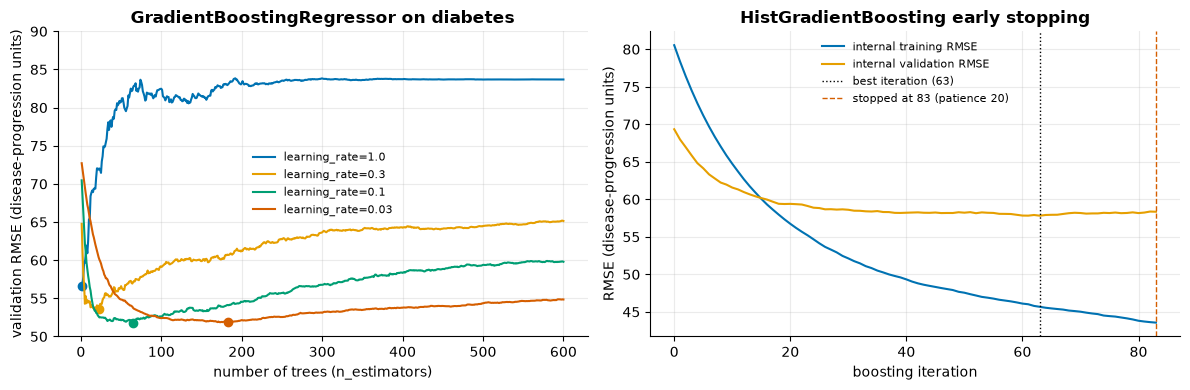

In [24]:
hgb_es = HistGradientBoostingRegressor(max_iter=1000, learning_rate=0.05, max_depth=3, early_stopping=True,
                                       validation_fraction=0.2, n_iter_no_change=20,
                                       random_state=RANDOM_STATE).fit(Xd_tr, yd_tr)
print(f"HGB stopped after {hgb_es.n_iter_} of 1000 iterations; "
      f"val RMSE = {mean_squared_error(yd_val, hgb_es.predict(Xd_val)) ** 0.5:.2f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for lr, c in lr_curves.items():
    axes[0].plot(np.arange(1, len(c) + 1), c, label=f"learning_rate={lr}")
    axes[0].plot(c.argmin() + 1, c.min(), "o", color=axes[0].lines[-1].get_color())
axes[0].set(title="GradientBoostingRegressor on diabetes", xlabel="number of trees (n_estimators)",
            ylabel="validation RMSE (disease-progression units)", ylim=(50, 90))
axes[0].legend(fontsize=8)
# HGB stores the (negative) loss on its internal validation split; loss is half squared error.
val_rmse_internal = np.sqrt(-2 * hgb_es.validation_score_)
train_rmse_internal = np.sqrt(-2 * hgb_es.train_score_)
axes[1].plot(train_rmse_internal, label="internal training RMSE")
axes[1].plot(val_rmse_internal, label="internal validation RMSE")
best_it = val_rmse_internal.argmin()
axes[1].axvline(best_it, color="k", ls=":", lw=1, label=f"best iteration ({best_it})")
axes[1].axvline(hgb_es.n_iter_, color=PALETTE[3], ls="--", lw=1,
                label=f"stopped at {hgb_es.n_iter_} (patience 20)")
axes[1].set(title="HistGradientBoosting early stopping", xlabel="boosting iteration",
            ylabel="RMSE (disease-progression units)")
axes[1].legend(fontsize=8)
fig.tight_layout()
savefig("lr_and_early_stopping")
plt.show()

With `learning_rate=1.0` the validation error is lowest right after the first tree and then climbs as the
ensemble overfits; smaller rates descend more slowly and more smoothly. Rule of thumb: pick a small learning
rate (0.05–0.1), then let early stopping choose the number of trees.

## 9 · Head-to-head comparison with cross-validation

Finally, the four model families with near-default settings, evaluated with 5-fold CV on a classification task
(breast cancer) and a regression task (diabetes). Trees need no feature scaling, so no pipeline is needed here.

In [25]:
def compare(models, X, y, cv, scoring):
    rows = []
    for name, model in models.items():
        res = cross_validate(model, X, y, cv=cv, scoring=scoring, n_jobs=-1)
        row = {"model": name}
        for key in scoring:
            vals = res[f"test_{key}"]
            if key.startswith("neg_"):
                vals, key = -vals, key[4:]
            row[f"{key} mean"], row[f"{key} std"] = vals.mean(), vals.std()
        row["fit time (s)"] = res["fit_time"].mean()
        rows.append(row)
    return pd.DataFrame(rows).set_index("model")


clf_models = {
    "Decision tree (depth 4)": DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE),
    "Random forest (300)": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "Gradient boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=RANDOM_STATE),
}
t0 = time.time()
clf_table = compare(clf_models, Xc, yc, StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE),
                    ["accuracy", "roc_auc"])
print(f"breast cancer comparison ({time.time() - t0:.1f}s)")
clf_table.round(3)

breast cancer comparison (2.6s)


,accuracy mean,accuracy std,roc_auc mean,roc_auc std,fit time (s)
model,,,,,
Decision tree (depth 4),0.923,0.030,0.915,0.037,0.021
Random forest (300),0.953,0.013,0.989,0.008,0.722
Gradient boosting,0.949,0.024,0.993,0.004,0.454
HistGradientBoosting,0.967,0.013,0.992,0.006,0.214


In [26]:
reg_models = {
    "Decision tree (depth 3)": DecisionTreeRegressor(max_depth=3, random_state=RANDOM_STATE),
    "Random forest (300)": RandomForestRegressor(n_estimators=300, min_samples_leaf=5,
                                                 random_state=RANDOM_STATE),
    "Gradient boosting": GradientBoostingRegressor(learning_rate=0.05, max_depth=2, n_estimators=200,
                                                   random_state=RANDOM_STATE),
    "HistGradientBoosting": HistGradientBoostingRegressor(learning_rate=0.05, max_depth=3, max_iter=200,
                                                          random_state=RANDOM_STATE),
}
reg_table = compare(reg_models, Xd, yd, KFold(5, shuffle=True, random_state=RANDOM_STATE),
                    ["r2", "neg_root_mean_squared_error"])
reg_table.round(3)

,r2 mean,r2 std,root_mean_squared_error mean,root_mean_squared_error std,fit time (s)
model,,,,,
Decision tree (depth 3),0.326,0.076,62.572,2.456,0.005
Random forest (300),0.442,0.091,56.840,3.401,0.604
Gradient boosting,0.454,0.088,56.190,3.068,0.303
HistGradientBoosting,0.439,0.091,56.931,3.297,0.166


A single tree is clearly the weakest; the ensembles are close to each other. On small, noisy tabular data
like diabetes, a strongly regularised boosted model or forest is about as good as it gets (a plain linear
model is also competitive there — always keep a simple baseline!).

> **Further reading / other libraries.** XGBoost, LightGBM and CatBoost are highly optimised gradient-boosting
> libraries (regularised objectives, second-order gradients, GPU training, native categorical handling). They
> are not installed in this course environment, but everything here — trees fitted to gradients, shrinkage,
> early stopping — carries over directly; `HistGradientBoosting*` is scikit-learn's LightGBM-style implementation.

## Key takeaways

- A tree greedily picks the split that maximises the weighted impurity decrease (Gini / entropy for
  classification, MSE for regression); boundaries are **axis-aligned** and piecewise constant.
- Unrestricted trees overfit; control them with `max_depth`, `min_samples_leaf`, or **cost-complexity pruning**
  (`ccp_alpha`) chosen by cross-validation.
- Trees are **unstable** (high variance). **Bagging** averages bootstrap trees; **random forests** additionally
  subsample features per split to decorrelate trees ($\rho\sigma^2 + (1-\rho)\sigma^2/B$). OOB score is a free
  validation estimate. More trees never hurt accuracy, only time.
- **Gradient boosting** fits shallow trees sequentially to the negative gradient (residuals for squared loss);
  the **learning rate** and **number of trees** trade off, and **early stopping** picks the latter.
- `HistGradientBoosting*` is the fast, modern default for tabular data in scikit-learn; always compare against
  a single-tree and a linear baseline with cross-validation.

## Exercises

1. **Entropy split.** Re-run the from-scratch split search with `impurity=entropy` and compare to
   `DecisionTreeClassifier(criterion="entropy", max_depth=1)`. *Hint:* `best_split` accepts the impurity function.
2. **Regression split from scratch.** Write `best_split_mse(x, y)` using cumulative sums of $y$ and $y^2$, and
   verify against `DecisionTreeRegressor(max_depth=1)` on one diabetes feature. *Hint:*
   $n\,\text{Var} = \sum y^2 - (\sum y)^2/n$.
3. **max_features sweep.** Plot the random-forest OOB error against `max_features` in {1, 2, 5, 10, 20, 30} at
   300 trees. Where is the sweet spot? *Hint:* reuse the `oob_score=True` loop.
4. **Absolute-loss boosting.** Change `ScratchGBR` to minimise absolute error: the negative gradient is
   $\operatorname{sign}(y - F)$, and each leaf value should be the **median** residual in that leaf. Compare with
   `GradientBoostingRegressor(loss="absolute_error")`. *Hint:* use `tree.apply(X)` to find leaf membership.
5. **Stochastic boosting.** Add a `subsample` parameter to `ScratchGBR` (fit each tree on a random fraction of
   rows) and show its effect on the diabetes validation curve. *Hint:* this is Friedman's *stochastic* gradient
   boosting (2002).